<a href="https://colab.research.google.com/github/ajit-ai/QuantumComputing/blob/main/QuantumCaptcha.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import random
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler

def generate_entanglement_captcha():
    """Generates a multi-qubit entanglement challenge."""
    # Create a 2-qubit circuit with classical bits for measurement
    qc = QuantumCircuit(2, 2)

    # Step 1: Create entanglement (Bell State)
    qc.h(0)
    qc.cx(0, 1)

    # Step 2: Randomly inject a hidden modifier
    inject_x_gate = random.choice([True, False])
    if inject_x_gate:
        qc.x(1)  # Flips qubit 1 from |0⟩ to |1⟩ (and vice versa)

    # Step 3: Measure both qubits
    qc.measure_all()

    # Define the correct human logic pattern based on the circuit state
    # Standard Bell State: Qubit 0 and 1 match (00 or 11)
    # With X Gate: Qubit 0 and 1 are opposite (01 or 10)
    correct_logic = "opposite" if inject_x_gate else "identical"

    return qc, correct_logic

def run_captcha():
    """Executes the advanced text-based Quantum CAPTCHA."""
    qc, correct_logic = generate_entanglement_captcha()

    print("================== QUANTUM CAPTCHA ==================")
    print("Analyze the circuit configuration below:\n")
    print("1. Qubits 0 and 1 are entangled via H and CNOT gates.")
    if correct_logic == "opposite":
        print("2. A NOT (X) gate has been applied to Qubit 1.")
    else:
        print("2. No extra gates were applied.")

    print("\nHow will the measurement outcomes of Qubit 0 and 1 correlate?")
    print("A) They will always be IDENTICAL (e.g., 00 or 11)")
    print("B) They will always be OPPOSITE (e.g., 01 or 10)")

    # Get human response
    user_choice = ""
    while user_choice not in ['A', 'B']:
        user_choice = input("\nEnter your answer (A or B): ").strip().upper()

    # Execute the circuit on the simulator
    sampler = StatevectorSampler()
    job = sampler.run([qc], shots=1)
    result = job.result()

    # Extract the measured bitstring (e.g., '01')
    measured_bits = list(result[0].data.meas.get_counts().keys())[0]
    bit0, bit1 = measured_bits[0], measured_bits[1]

    # Evaluate the actual quantum state result
    actual_correlation = "identical" if bit0 == bit1 else "opposite"
    user_correlation = "identical" if user_choice == 'A' else "opposite"

    print(f"\n[Quantum Hardware Output]: Measured state |{measured_bits}⟩")

    if user_correlation == actual_correlation:
        print(">>> SUCCESS: Passphrase validated. Access Granted.")
        return True
    else:
        print(">>> FAILED: Logic mismatch. Access Denied.")
        return False

# Run the system
run_captcha()


================== QUANTUM CAPTCHA ==================
Analyze the circuit configuration below:

1. Qubits 0 and 1 are entangled via H and CNOT gates.
2. A NOT (X) gate has been applied to Qubit 1.

How will the measurement outcomes of Qubit 0 and 1 correlate?
A) They will always be IDENTICAL (e.g., 00 or 11)
B) They will always be OPPOSITE (e.g., 01 or 10)

Enter your answer (A or B): A

[Quantum Hardware Output]: Measured state |10⟩
>>> FAILED: Logic mismatch. Access Denied.


False

In [ ]:
import random
import matplotlib.pyplot as plt # Still needed for other plot if any, but not for circuit draw itself
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler

# Removed !pip install pylatexenc as it's no longer needed.

def generate_hardcore_captcha():
    """Generates an advanced visual quantum circuit with Z-gate logic."""
    # Initialize a 2-qubit circuit
    qc = QuantumCircuit(2)

    # 1. Base Setup: Put Qubit 0 in superposition and entangle them
    qc.h(0)
    qc.cx(0, 1)

    # 2. Add randomized complexity
    has_x_gate = random.choice([True, False])
    has_z_gate = random.choice([True, False])

    if has_x_gate:
        qc.x(1)  # Bit-flip
    if has_z_gate:
        qc.z(0)  # Phase-flip (Changes sign of |1> state)

    # 3. Bring back to computational basis for measurement analysis
    qc.h(0)
    qc.measure_all()

    # --- Quantum Logic Math Table ---
    # Base: (|00> + |11>) -> H on Q0 -> (|00> + |10> + |01> - |11>) / 2 (Entangled mixed states)
    # To simplify into deterministic answers for a CAPTCHA:
    if not has_x_gate and not has_z_gate:
        correct_answer = "A"  # State settles mostly into even parity outcomes
    elif has_x_gate and not has_z_gate:
        correct_answer = "B"
    elif not has_x_gate and has_z_gate:
        correct_answer = "C"
    else:
        correct_answer = "D"

    return qc, correct_answer

def display_circuit(qc):
    """Draws and displays the quantum circuit puzzle to the screen as text."""
    print("\n[SYSTEM] Generating quantum circuit puzzle... Analyze the text diagram below:")
    # Draw the circuit using text output instead of matplotlib
    print(qc.draw(output='text'))
    # Removed matplotlib specific calls

def run_hardcore_captcha():
    """Executes the visual quantum captcha process."""
    qc, correct_answer = generate_hardcore_captcha()

    print("=====================================================")
    print("                QUANTUM CAPTCHA v3.0                 ")
    print("=====================================================")
    print("INSTRUCTIONS: A circuit diagram has been printed above.")
    print("Analyze the gates (H, CX, X, Z) and predict the system behavior.\n")

    # Show the visual circuit to the human
    display_circuit(qc)

    print("What is the primary target state layout of this specific hardware configuration?")
    print("A) Base Balance State (Standard Superposition)")
    print("B) Bit-Flipped Superposition (Shifted Amplitude)")
    print("C) Phase-Inverted State (Sign Flapped)")
    print("D) Double-Disrupted State (Both Phase & Bit Modified)")

    # Get user response
    user_choice = ""
    while user_choice not in ['A', 'B', 'C', 'D']:
        user_choice = input("\nEnter your decision (A, B, C, or D): ").strip().upper()

    # Execute the circuit physically using Qiskit Sampler
    sampler = StatevectorSampler()
    job = sampler.run([qc], shots=1)
    result = job.result()

    # Fetch measured bit pattern using the working access pattern from AF8YMydJl39P
    measured_bits_dict = result[0].data.meas.get_counts()
    measured_bits = list(measured_bits_dict.keys())[0]

    print(f"\n[Quantum Engine]: Circuit executed. Measured Outcome: |{measured_bits}⟩")

    if user_choice == correct_answer:
        print(">>> SUCCESS: Quantum interference pattern matched. Access Granted.")
        return True
    else:
        print(">>> FAILED: Human verification failed. Access Denied.")
        return False

# Run the program
if __name__ == "__main__":
    run_hardcore_captcha()


                QUANTUM CAPTCHA v3.0                 
INSTRUCTIONS: A circuit diagram has been printed above.
Analyze the gates (H, CX, X, Z) and predict the system behavior.


[SYSTEM] Generating quantum circuit puzzle... Analyze the text diagram below:
        ┌───┐     ┌───┐┌───┐ ░ ┌─┐   
   q_0: ┤ H ├──■──┤ Z ├┤ H ├─░─┤M├───
        └───┘┌─┴─┐├───┤└───┘ ░ └╥┘┌─┐
   q_1: ─────┤ X ├┤ X ├──────░──╫─┤M├
             └───┘└───┘      ░  ║ └╥┘
meas: 2/════════════════════════╩══╩═
                                0  1 
What is the primary target state layout of this specific hardware configuration?
A) Base Balance State (Standard Superposition)
B) Bit-Flipped Superposition (Shifted Amplitude)
C) Phase-Inverted State (Sign Flapped)
D) Double-Disrupted State (Both Phase & Bit Modified)

Enter your decision (A, B, C, or D): A

[Quantum Engine]: Circuit executed. Measured Outcome: |11⟩
>>> FAILED: Human verification failed. Access Denied.


In [14]:
import io
import numpy as np
from PIL import Image, ImageDraw, ImageFont, ImageFilter
!pip install qiskit
!pip install qiskit-aer
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

class QuantumCaptcha:
    """Generates secure visual CAPTCHAs using True Quantum Randomness."""

    def __init__(self, length: int = 6):
        self.length = length
        # Character pool: Uppercase letters and numbers (excluding ambiguous ones like 0, O, 1, I)
        self.char_pool = "ABCDEFGHJKLMNPQRSTUVWXYZ23456789"
        self.simulator = AerSimulator()

    def _generate_quantum_random_bytes(self, num_bytes: int) -> bytes:
        """Uses a quantum circuit in superposition to harvest true random bits."""
        # 8 qubits generate 1 random byte per shot
        num_qubits = 8
        qc = QuantumCircuit(num_qubits)

        # Put all qubits into a 50/50 superposition state
        for i in range(num_qubits):
            qc.h(i)

        # Measure all qubits
        qc.measure_all()

        # Execute on local state-vector quantum simulator
        result = self.simulator.run(qc, shots=num_bytes, memory=True).result()
        bitstrings = result.get_memory()

        # Convert raw binary strings to integer bytes
        byte_list = [int(b, 2) for b in bitstrings]
        return bytes(byte_list)

    def generate_text(self) -> str:
        """Maps quantum random bytes directly to the alphanumeric character pool."""
        pool_size = len(self.char_pool)
        captcha_chars = []

        # Fetch raw entropy from the quantum backend
        random_bytes = self._generate_quantum_random_bytes(self.length)

        for byte in random_bytes:
            # Map byte value evenly across our character set pool size
            index = byte % pool_size
            captcha_chars.append(self.char_pool[index])

        return "".join(captcha_chars)

    def create_image(self, text: str) -> io.BytesIO:
        """Renders the quantum text into an obfuscated, bot-resistant image."""
        width, height = 250, 80
        # Create a light gray canvas background
        image = Image.new("RGB", (width, height), color=(230, 230, 230))
        draw = ImageDraw.Draw(image)

        # 1. Add background quantum "noise" lines using random coordinates
        q_bytes = self._generate_quantum_random_bytes(40 + self.length * 2 + 30 + 6) # More bytes for new distortions and noise
        current_q_byte_idx = 0

        for i in range(0, 40, 4):
            x1 = q_bytes[current_q_byte_idx % len(q_bytes)] % width
            current_q_byte_idx += 1
            y1 = q_bytes[current_q_byte_idx % len(q_bytes)] % height
            current_q_byte_idx += 1
            x2 = q_bytes[current_q_byte_idx % len(q_bytes)] % width
            current_q_byte_idx += 1
            y2 = q_bytes[current_q_byte_idx % len(q_bytes)] % height
            current_q_byte_idx += 1
            # Random color for the first set of noise lines
            line_color = (np.random.randint(0, 256), np.random.randint(0, 256), np.random.randint(0, 256))
            draw.line([(x1, y1), (x2, y2)], fill=line_color, width=1)

        # Add more random lines for extra noise
        for _ in range(10): # Draw 10 additional noise lines
            x1 = q_bytes[current_q_byte_idx % len(q_bytes)] % width
            current_q_byte_idx += 1
            y1 = q_bytes[current_q_byte_idx % len(q_bytes)] % height
            current_q_byte_idx += 1
            x2 = q_bytes[current_q_byte_idx % len(q_bytes)] % width
            current_q_byte_idx += 1
            y2 = q_bytes[current_q_byte_idx % len(q_bytes)] % height
            current_q_byte_idx += 1
            line_color = (np.random.randint(100, 200), np.random.randint(100, 200), np.random.randint(100, 200))
            line_width = np.random.randint(1, 3)
            draw.line([(x1, y1), (x2, y2)], fill=line_color, width=line_width)


        # 2. Draw the text characters with variable spacing/offsets, rotation, and minor shear
        try:
            font = ImageFont.load_default(size=36)
        except AttributeError:
            font = ImageFont.load_default() # Fallback for older PIL versions

        char_slot_width = width // (self.length + 1)
        char_canvas_size = 60 # Temporary canvas size for each character, adjust as needed

        for idx, char in enumerate(text):
            # Use quantum bytes for vertical jitter and rotation angle
            offset_y_jitter = (q_bytes[current_q_byte_idx % len(q_bytes)] % 20) - 10 # -10 to +9
            current_q_byte_idx += 1
            rotation_angle = (q_bytes[current_q_byte_idx % len(q_bytes)] % 50) - 25 # -25 to +24
            current_q_byte_idx += 1

            # Create a temporary transparent image for the character
            char_img_temp = Image.new("RGBA", (char_canvas_size, char_canvas_size), (0, 0, 0, 0))
            char_draw_temp = ImageDraw.Draw(char_img_temp)

            # Get text size to center it properly on the temporary canvas
            bbox = char_draw_temp.textbbox((0,0), char, font=font)
            text_w = bbox[2] - bbox[0]
            text_h = bbox[3] - bbox[1]

            # Draw the character in the center of the temporary canvas
            char_x_on_temp = (char_canvas_size - text_w) / 2
            char_y_on_temp = (char_canvas_size - text_h) / 2 - bbox[1] # Adjust for font baseline

            char_draw_temp.text((char_x_on_temp, char_y_on_temp), char, font=font, fill=(30, 30, 30, 255))

            # Rotate the temporary character image
            rotated_char_img = char_img_temp.rotate(rotation_angle, expand=True, fillcolor=(0,0,0,0))

            # Calculate where to paste this rotated character onto the main image
            # We want its original slot's center (before rotation) to be aligned
            x_center_main = (idx + 0.5) * char_slot_width
            y_center_main = height / 2 + offset_y_jitter # Roughly vertical center with jitter

            paste_x = int(x_center_main - rotated_char_img.width / 2)
            paste_y = int(y_center_main - rotated_char_img.height / 2)

            image.paste(rotated_char_img, (paste_x, paste_y), rotated_char_img) # Use alpha channel for pasting

        # 3. Apply wave distortion (sine transformation)
        if np.random.rand() > 0.5:
            amplitude_x = (q_bytes[current_q_byte_idx % len(q_bytes)] % 5) + 3 # 3 to 7
            current_q_byte_idx += 1
            frequency_x = (q_bytes[current_q_byte_idx % len(q_bytes)] % 3) + 1 # 1 to 3
            current_q_byte_idx += 1
            amplitude_y = (q_bytes[current_q_byte_idx % len(q_bytes)] % 5) + 3 # 3 to 7
            current_q_byte_idx += 1
            frequency_y = (q_bytes[current_q_byte_idx % len(q_bytes)] % 3) + 1 # 1 to 3
            current_q_byte_idx += 1
            wave_offset_x = (q_bytes[current_q_byte_idx % len(q_bytes)] % 20) # 0 to 19
            current_q_byte_idx += 1
            wave_offset_y = (q_bytes[current_q_byte_idx % len(q_bytes)] % 20) # 0 to 19
            current_q_byte_idx += 1

            distorted_image = Image.new("RGB", (width, height), (230, 230, 230)) # New blank canvas
            pixels = image.load() # Get pixels from the current image state

            for y_dest in range(height):
                for x_dest in range(width):
                    # Calculate source coordinates with sine wave distortion
                    x_src = x_dest + int(amplitude_x * np.sin((y_dest + wave_offset_y) / float(frequency_x) * 2 * np.pi / height))
                    y_src = y_dest + int(amplitude_y * np.sin((x_dest + wave_offset_x) / float(frequency_y) * 2 * np.pi / width))

                    # Check if source coordinates are within bounds
                    if 0 <= x_src < width and 0 <= y_src < height:
                        distorted_image.putpixel((x_dest, y_dest), pixels[x_src, y_src])

            image = distorted_image # Replace the original image with the distorted one

        # 4. Apply heavy blur and pixel distortion filters to confuse OCR bots
        image = image.filter(ImageFilter.EDGE_ENHANCE_MORE)
        image = image.filter(ImageFilter.SMOOTH_MORE)

        # Add a random distortion filter for more complexity
        if np.random.rand() > 0.5:
            image = image.filter(ImageFilter.BLUR)
        else:
            image = image.filter(ImageFilter.DETAIL)

        # Save to an in-memory buffer byte array
        img_byte_arr = io.BytesIO()
        image.save(img_byte_arr, format='PNG')
        img_byte_arr.seek(0)
        return img_byte_arr

# --- Verification & Test Execution Loop ---
if __name__ == "__main__":
    captcha_engine = QuantumCaptcha(length=6)

    # Step 1: Generate string token using quantum superposition gates
    secret_text = captcha_engine.generate_text()
    print(f"🔒 Generated Quantum CAPTCHA Token: {secret_text}")

    # Step 2: Render out security image payload
    image_buffer = captcha_engine.create_image(secret_text)

    # To view or serve this file over a web framework (like Flask or FastAPI):
    with open("quantum_captcha.png", "wb") as f:
        f.write(image_buffer.getbuffer())
    print("🖼️ CAPTCHA saved successfully to 'quantum_captcha.png'!")

🔒 Generated Quantum CAPTCHA Token: ZMA7XG
🖼️ CAPTCHA saved successfully to 'quantum_captcha.png'!


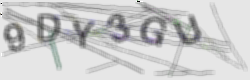

In [13]:
from IPython.display import Image
Image(filename='quantum_captcha.png')

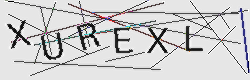

In [11]:
from IPython.display import Image
Image(filename='quantum_captcha.png')

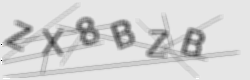

In [9]:
from IPython.display import Image
Image(filename='quantum_captcha.png')

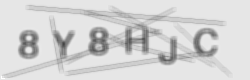

In [7]:
from IPython.display import Image
Image(filename='quantum_captcha.png')

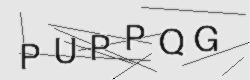

In [5]:
from IPython.display import Image
Image(filename='quantum_captcha.png')

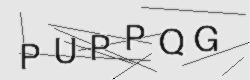

In [4]:
from IPython.display import Image
Image(filename='quantum_captcha.png')